# Data Exploration Traffic Dataset

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
# Load the dataset

data = np.load('data/dataset.npz')
X_train = data["X_train"]  # [1261, 36, 48]
Y_train = data["Y_train"]  # [1261, 36]
X_test = data["X_test"]  # [840, 36, 48]
Y_test = data["Y_test"]  # [840, 36]
adj_mat = data["adj_mat"]  # [36, 36]

## Understanding the column order
As there are no labels in the dataset, it is hard to tell with 100% accuracy which columns represents which.
I'm sure the first 10 columns are the traffic volume.
But then, things get blurry.

- 0-9: historical sequence, 10 most recent data points
- 10-16: Week day
- ERROR: 17-41: Hours of day -> Column 39: Weird output, not binary, but integre with values of 5

In [3]:
# Flatten
X_flat = X_train.reshape(-1, X_train.shape[-1])  # [1261*36, 48]

# Variance per feature
variances = X_flat.var(axis=0)

df = pd.DataFrame({
    "column": np.arange(X_train.shape[-1]),
    "variance": variances
})

print(df)

    column  variance
0        0  0.039828
1        1  0.039846
2        2  0.039861
3        3  0.039869
4        4  0.039868
5        5  0.039860
6        6  0.039847
7        7  0.039830
8        8  0.039823
9        9  0.039829
10      10  0.176278
11      11  0.176270
12      12  0.176262
13      13  0.136091
14      14  0.129032
15      15  0.042425
16      16  0.042425
17      17  0.042425
18      18  0.040241
19      19  0.039543
20      20  0.039543
21      21  0.039543
22      22  0.039543
23      23  0.039543
24      24  0.039543
25      25  0.039543
26      26  0.039543
27      27  0.039543
28      28  0.039543
29      29  0.039543
30      30  0.039543
31      31  0.039543
32      32  0.039543
33      33  0.039543
34      34  0.039543
35      35  0.039543
36      36  0.039543
37      37  0.039543
38      38  0.039543
39      39  0.693629
40      40  0.172815
41      41  0.237670
42      42  0.098789
43      43  0.200583
44      44  0.243098
45      45  0.212214
46      46  0

In [4]:
for col in range(X_train.shape[-1]):
    unique_vals = np.unique(X_train[..., col])
    if len(unique_vals) <= 3:
        print(f"Column {col}: {unique_vals}")

# Just states that columns 0-9 and 39 are not binary. The rest is binary.

Column 10: [0. 1.]
Column 11: [0. 1.]
Column 12: [0. 1.]
Column 13: [0. 1.]
Column 14: [0. 1.]
Column 15: [0. 1.]
Column 16: [0. 1.]
Column 17: [0. 1.]
Column 18: [0. 1.]
Column 19: [0. 1.]
Column 20: [0. 1.]
Column 21: [0. 1.]
Column 22: [0. 1.]
Column 23: [0. 1.]
Column 24: [0. 1.]
Column 25: [0. 1.]
Column 26: [0. 1.]
Column 27: [0. 1.]
Column 28: [0. 1.]
Column 29: [0. 1.]
Column 30: [0. 1.]
Column 31: [0. 1.]
Column 32: [0. 1.]
Column 33: [0. 1.]
Column 34: [0. 1.]
Column 35: [0. 1.]
Column 36: [0. 1.]
Column 37: [0. 1.]
Column 38: [0. 1.]
Column 40: [0. 1.]
Column 41: [0. 1.]
Column 42: [0. 1.]
Column 43: [0. 1.]
Column 44: [0. 1.]
Column 45: [0. 1.]
Column 46: [0. 1.]
Column 47: [0. 1.]


In [5]:
from collections import defaultdict

X = X_train.reshape(-1, X_train.shape[-1])  # [45396, 48]

binary_cols = []
for col in range(X.shape[1]):
    vals = np.unique(X[:, col])
    if set(vals).issubset({0, 1}):
        binary_cols.append(col)

groups = []

remaining = set(binary_cols)

while remaining:
    col = remaining.pop()
    group = {col}

    for other_col in list(remaining):
        candidate_group = sorted(group | {other_col})

        # Check if at most one column is active per row
        row_sums = X[:, candidate_group].sum(axis=1)

        if np.all(row_sums <= 1):
            group.add(other_col)
            remaining.remove(other_col)

    groups.append(sorted(group))

print("Mutually exclusive binary groups:")

for g in groups:
    row_sums = X[:, g].sum(axis=1)

    if np.all(row_sums == 1):
        status = "complete one-hot"
    elif np.all(row_sums <= 1):
        status = "mutually exclusive, but not always active"
    else:
        status = "not one-hot"

    print(f"{g}: {status}")

Mutually exclusive binary groups:
[10, 11, 12, 13, 14]: complete one-hot
[15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38]: complete one-hot
[40, 41, 42, 43]: complete one-hot
[44, 45, 46, 47]: complete one-hot


In [6]:
blocks = {
    "weekday_candidate": range(10, 15),
    "hour_candidate": range(15, 39),
    "unknown_col_39": [39],
    "direction_candidate": range(40, 44),
    "road_candidate": range(44, 48),
}

X = X_train.reshape(-1, X_train.shape[-1])

for name, cols in blocks.items():
    cols = list(cols)
    sums = X[:, cols].sum(axis=1)

    print(name, cols)
    print("unique row sums:", np.unique(sums))
    print()

weekday_candidate [10, 11, 12, 13, 14]
unique row sums: [1.]

hour_candidate [15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38]
unique row sums: [1.]

unknown_col_39 [39]
unique row sums: [1. 2. 3. 4. 5.]

direction_candidate [40, 41, 42, 43]
unique row sums: [1.]

road_candidate [44, 45, 46, 47]
unique row sums: [1.]



## Graphical exploration
Fully connected graph

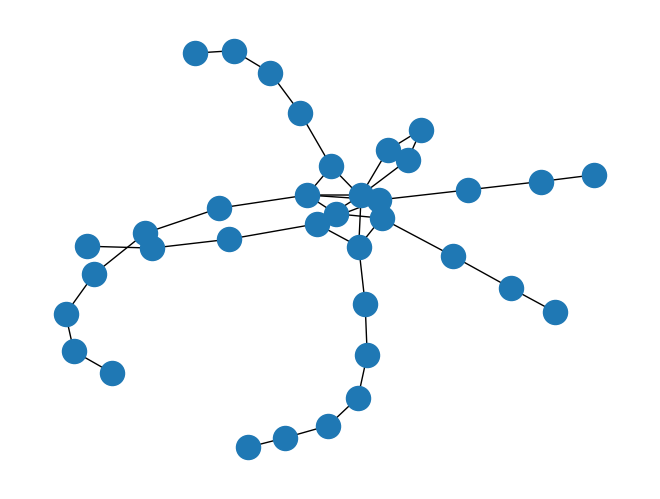

In [7]:
import networkx as nx

G = nx.from_numpy_array(adj_mat)
nx.draw(G)

## Distributions

Traffic volume: All the same input distribution, so I united them.

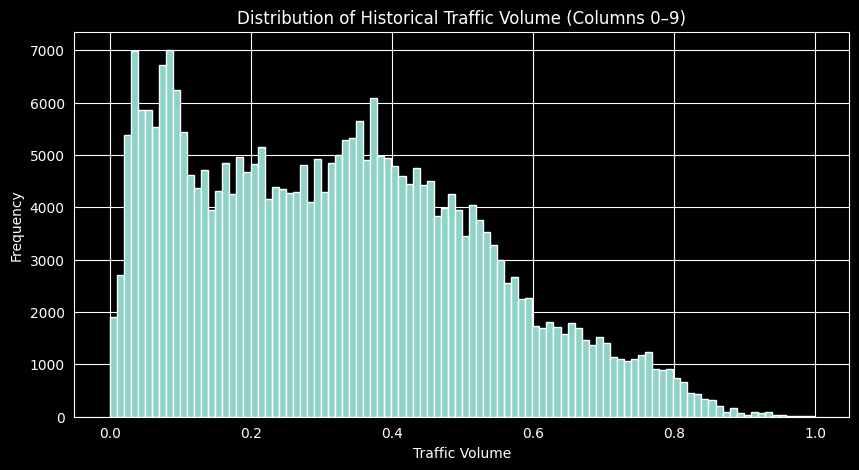

In [20]:
traffic_history = X_train[:, :, :10]   # samples × nodes × time-lags
traffic_values = traffic_history.reshape(-1)

std_traf = traffic_history.std()
mean_traf = traffic_history.mean()
traffic_values_stand = (traffic_values - mean_traf)/std_traf

plt.figure(figsize=(10,5))
plt.hist(traffic_values, bins=100)
plt.title("Distribution of Historical Traffic Volume (Columns 0–9)")
plt.xlabel("Traffic Volume")
plt.ylabel("Frequency")
plt.show()

* Standardization makes sense. GRU uses tanh and sigmoid activation functions, which work best when inputs are standardized.
* Distribution is bimodal. We can use bucketizing or add a feature for each of the modes. Maybe even better you Gaussian Mixture model before to cluster to mode. Would be data driven parameters instead of hand crafted.

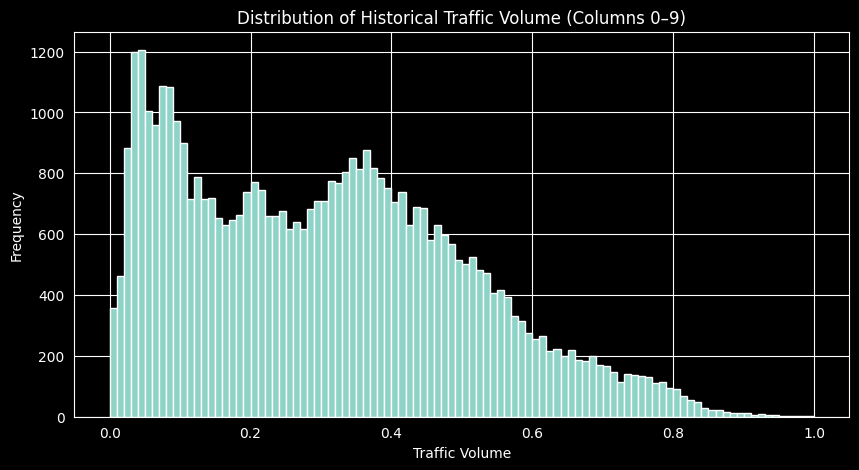

In [26]:
plt.figure(figsize=(10,5))
plt.hist(Y_train.reshape(-1), bins=100)
plt.title("Distribution of Historical Traffic Volume (Columns 0–9)")
plt.xlabel("Traffic Volume")
plt.ylabel("Frequency")
plt.show()

In [27]:
std_label, std_mean = Y_train.reshape(-1).std(), Y_train.reshape(-1).mean()
print(f"Label mean: {std_mean}, Label std: {std_label}")
print(f"Traffic mean: {mean_traf}, Traffic std: {std_traf}")

Label mean: 0.30427032709121704, Label std: 0.19957737624645233
Traffic mean: 0.32229870557785034, Traffic std: 0.20467467606067657


Label and features 0-9 have same distribution

### Bucketizing traffic history into regimes

I tried bucketizing with the function below. It did not improve RMSE, but convergence was ~25 epochs faster.

In [ ]:
def add_traffic_buckets(X, n_buckets=5, traffic_idx=range(10), bin_edges=None):
    """
    Bucketize historical traffic columns into one-hot encoded traffic regime features.

    Parameters:
        X: shape [samples, sensors, features]
        n_buckets: number of traffic regimes
        traffic_idx: columns containing historical traffic
        bin_edges: optional custom edges

    Returns:
        X_new: original X + bucket features
        bin_edges: learned bucket boundaries
    """

    traffic = X[:, :, traffic_idx].reshape(-1)

    # Learn quantile-based bins from training data
    if bin_edges is None:
        bin_edges = np.quantile(
            traffic,
            q=np.linspace(0, 1, n_buckets + 1)
        )

        # Ensure proper edges
        bin_edges[0] = -np.inf
        bin_edges[-1] = np.inf

    bucket_features = []

    for col in traffic_idx:
        vals = X[:, :, col]
        bucket_ids = np.digitize(vals, bin_edges[1:-1])   # shape [samples, sensors]

        one_hot = np.eye(n_buckets, dtype=np.float32)[bucket_ids]
        bucket_features.append(one_hot)

    # Concatenate all bucketized columns
    bucket_features = np.concatenate(bucket_features, axis=-1)

    # Append to original feature tensor
    X_new = np.concatenate([X, bucket_features], axis=-1)

    return X_new, bin_edges

In [37]:
from sklearn.mixture import GaussianMixture

# traffic history columns: first 10 features
traffic = X_train[:, :, :10].reshape(-1, 1)

gmm = GaussianMixture(
    n_components=5,      # try 4 first
    covariance_type="full",
    random_state=523
)

gmm.fit(traffic)

,"n_components n_components: int, default=1The number of mixture components.",5
,"covariance_type covariance_type: {'full', 'tied', 'diag', 'spherical'}, default='full'String describing the type of covariance parameters to use.Must be one of:- 'full': each component has its own general covariance matrix.- 'tied': all components share the same general covariance matrix.- 'diag': each component has its own diagonal covariance matrix.- 'spherical': each component has its own single variance.For an example of using `covariance_type`, refer to:ref:`sphx_glr_auto_examples_mixture_plot_gmm_selection.py`.",'full'
,"tol tol: float, default=1e-3The convergence threshold. EM iterations will stop when thelower bound average gain is below this threshold.",0.001
,"reg_covar reg_covar: float, default=1e-6Non-negative regularization added to the diagonal of covariance.Allows to assure that the covariance matrices are all positive.",1e-06
,"max_iter max_iter: int, default=100The number of EM iterations to perform.",100
,"n_init n_init: int, default=1The number of initializations to perform. The best results are kept.",1
,"init_params init_params: {'kmeans', 'k-means++', 'random', 'random_from_data'}, default='kmeans'The method used to initialize the weights, the means and theprecisions.String must be one of:- 'kmeans' : responsibilities are initialized using kmeans.- 'k-means++' : use the k-means++ method to initialize.- 'random' : responsibilities are initialized randomly.- 'random_from_data' : initial means are randomly selected data points... versionchanged:: v1.1 `init_params` now accepts 'random_from_data' and 'k-means++' as initialization methods.",'kmeans'
,"weights_init weights_init: array-like of shape (n_components, ), default=NoneThe user-provided initial weights.If it is None, weights are initialized using the `init_params` method.",None
,"means_init means_init: array-like of shape (n_components, n_features), default=NoneThe user-provided initial means,If it is None, means are initialized using the `init_params` method.",None
,"precisions_init precisions_init: array-like, default=NoneThe user-provided initial precisions (inverse of the covariancematrices).If it is None, precisions are initialized using the 'init_params'method.The shape depends on 'covariance_type':: (n_components,) if 'spherical', (n_features, n_features) if 'tied', (n_components, n_features) if 'diag', (n_components, n_features, n_features) if 'full'",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given to the method chosen to initialize theparameters (see `init_params`).In addition, it controls the generation of random samples from thefitted distribution (see the method `sample`).Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",523


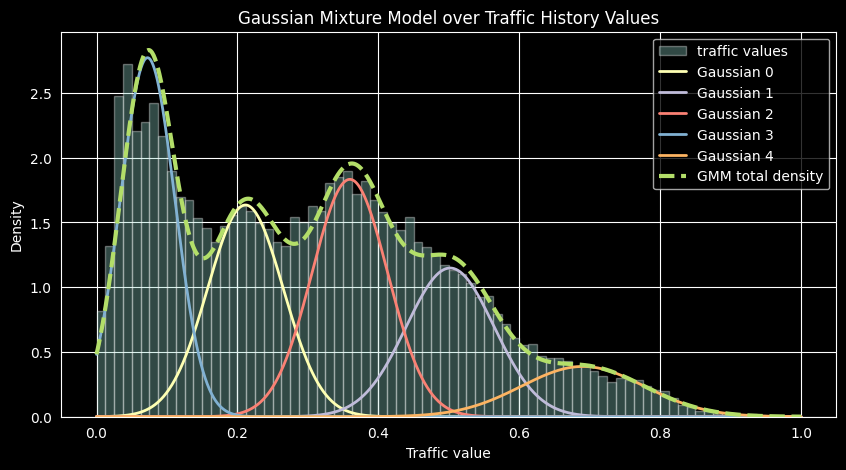

In [38]:
x_grid = np.linspace(traffic.min(), traffic.max(), 1000).reshape(-1, 1)

log_probs = gmm.score_samples(x_grid)
total_density = np.exp(log_probs)

responsibilities = gmm.predict_proba(x_grid)

plt.figure(figsize=(10, 5))

plt.hist(
    traffic.ravel(),
    bins=80,
    density=True,
    alpha=0.35,
    label="traffic values"
)

for k in range(gmm.n_components):
    component_density = (
        responsibilities[:, k] * total_density
    )

    plt.plot(
        x_grid.ravel(),
        component_density,
        linewidth=2,
        label=f"Gaussian {k}"
    )

plt.plot(
    x_grid.ravel(),
    total_density,
    linewidth=3,
    linestyle="--",
    label="GMM total density"
)

plt.xlabel("Traffic value")
plt.ylabel("Density")
plt.title("Gaussian Mixture Model over Traffic History Values")
plt.legend()
plt.show()

In [32]:
means = gmm.means_.ravel()
stds = np.sqrt(gmm.covariances_.reshape(-1))
weights = gmm.weights_

order = np.argsort(means)

for i in order:
    print(
        f"Mode {i}: "
        f"mean={means[i]:.4f}, "
        f"std={stds[i]:.4f}, "
        f"weight={weights[i]:.3f}"
    )

Mode 3: mean=0.0725, std=0.0387, weight=0.269
Mode 0: mean=0.2114, std=0.0536, weight=0.220
Mode 2: mean=0.3596, std=0.0537, weight=0.247
Mode 1: mean=0.5019, std=0.0623, weight=0.179
Mode 4: mean=0.6903, std=0.0873, weight=0.085


Using this GMM significantly improves convergence speed. We get the same RMSE for 64 epochs instead of 10. Tried different seeds. Also tried to feed it into the static part as well as the GRU. Feeding into GRU made it worse.